# 🛒 Mall Customer Segmentation using K-Means Clustering

##  Project Overview
This project applies **Unsupervised Machine Learning** techniques to segment mall customers based on their purchasing behavior. By analyzing annual income and spending scores, we aim to identify distinct customer personas to help the marketing team design targeted campaigns.

**Algorithm Used:** K-Means Clustering.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df=pd.read_csv(r'D:\DEPI 2025-2026\MLOps\ML\Mall_Customr_Segmentation_Project\Mall_Customers.csv')
df.head(20)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## 📊 1. Exploratory Data Analysis (EDA) & Visualization
Before feeding the data to the model, we explore the relationships between different features (Gender, Age, Annual Income, and Spending Score) to find initial patterns.
* **Goal:** Understand feature distributions and find the best features for clustering.

In [18]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [19]:
print('Duplicated:',df.duplicated().sum())
df.isna().sum()

Duplicated: 0


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Text(0.5, 1.0, 'Gender Distribution')

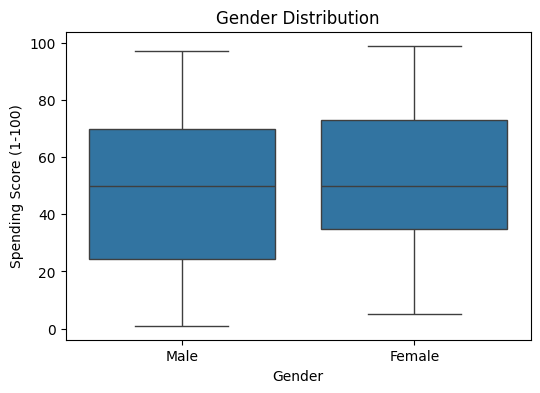

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df)
plt.title("Gender Distribution")

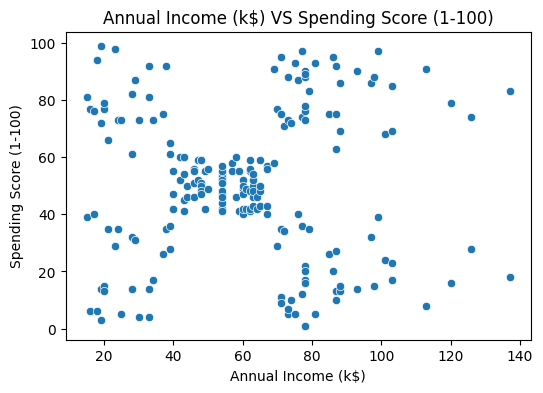

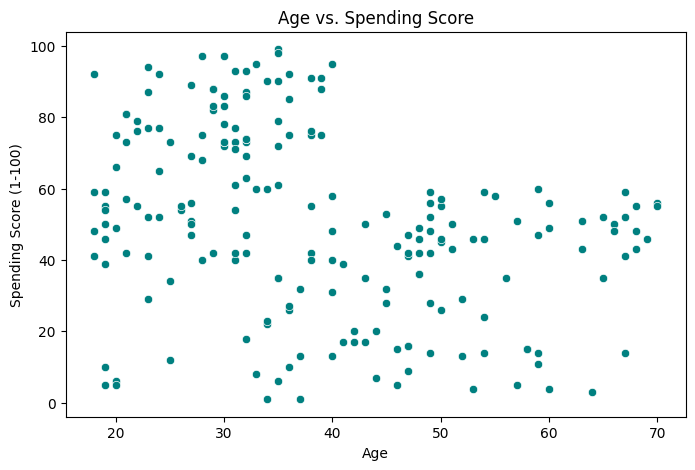

In [21]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)')
plt.title("Annual Income (k$) VS Spending Score (1-100)")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df, color='teal')
plt.title("Age vs. Spending Score")
plt.show()

In [22]:
df=df.drop("CustomerID",axis=1)

## 📐 2. Determining the Optimal Number of Clusters (K)
To ensure our K-Means model performs optimally, we must find the correct number of clusters mathematically. We will use two proven methods:
1. **The Elbow Method** (Using WCSS / Inertia)
2. **Silhouette Analysis** (To measure cluster density and separation)

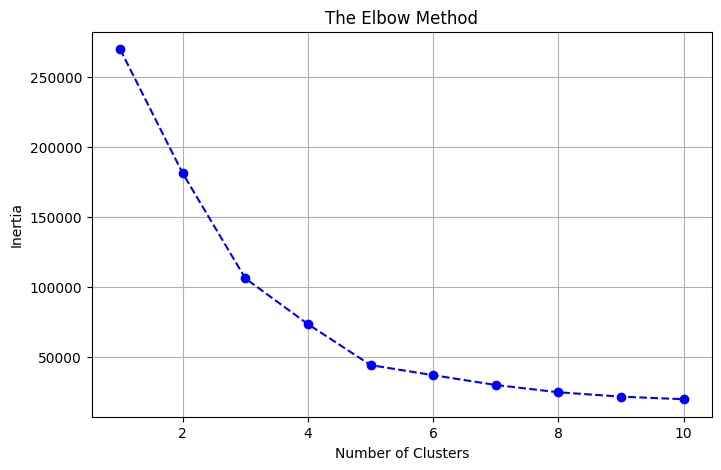

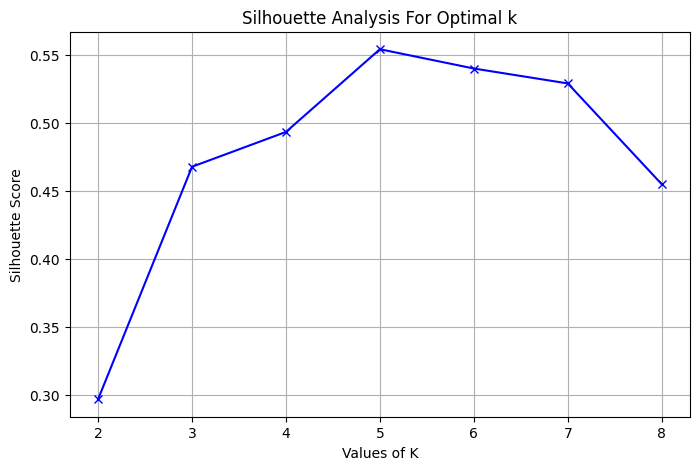

In [23]:

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

inertias = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_) 
    
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker='o', linestyle='--', color='blue')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)

#Silhouette Analysis 
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
silhouette_avg = []

for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(X)
    cluster_labels = kmeans.labels_
    
    score = silhouette_score(X, cluster_labels)
    silhouette_avg.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, silhouette_avg, 'bx-')
plt.xlabel('Values of K') 
plt.ylabel('Silhouette Score') 
plt.title('Silhouette Analysis For Optimal k')
plt.grid(True)
plt.show()

## 3. Model Building: K-Means Clustering (K=5)
Based on the Elbow and Silhouette methods, the optimal number of clusters is **5**. We will now train the K-Means model and visualize the final customer segments along with their centroids.

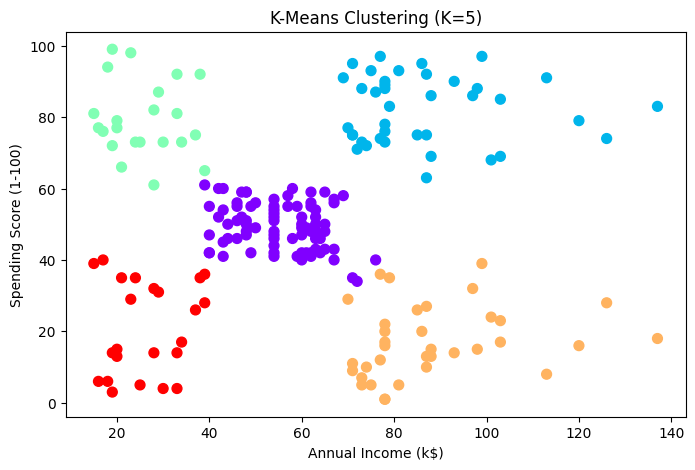

In [24]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X)

plt.figure(figsize=(8, 5))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=kmeans.labels_, cmap='rainbow', s=50)
plt.title('K-Means Clustering (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

## For Deploy

In [25]:
import joblib
joblib.dump(kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']